This project detects deforestation using Digital Image Processing by comparing BEFORE and AFTER satellite images.

The system uses:

Normalization
Gaussian Filtering
Image Difference
Thresholding
Contour Detection
Area Change Estimation

This provides a simple and efficient solution for land-cover change detection.

In [2]:
!pip install kagglehub

In [3]:
import kagglehub
import os
import glob
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [4]:
path = kagglehub.dataset_download(
    "akileshga/deforestation-non-deforestation-area-analysis"
)

print("Dataset downloaded at:", path)

100%|██████████| 44.4M/44.4M [00:00<00:00, 78.8MB/s]

Extracting files...


Dataset downloaded at: /root/.cache/kagglehub/datasets/akileshga/deforestation-non-deforestation-area-analysis/versions/1


In [5]:
for root, dirs, files in os.walk(path):
    print(root)
    print("Folders:", dirs[:5])
    print("Files:", files[:5])
    print("-" * 50)

/root/.cache/kagglehub/datasets/akileshga/deforestation-non-deforestation-area-analysis/versions/1
Folders: ['no_deforestation', 'deforestation']
Files: []
--------------------------------------------------
/root/.cache/kagglehub/datasets/akileshga/deforestation-non-deforestation-area-analysis/versions/1/no_deforestation
Folders: []
Files: ['img40.png', 'img52.png', 'img48.png', 'img1.png', 'img50.png']
--------------------------------------------------
/root/.cache/kagglehub/datasets/akileshga/deforestation-non-deforestation-area-analysis/versions/1/deforestation
Folders: []
Files: ['img40.png', 'img48.png', 'img61.png', 'img50.png', 'img16.jpeg']
--------------------------------------------------


The following helper functions perform all major DIP operations and calculate final deforestation percentage.

In [6]:
def load_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img


def normalize_image(img):
    img_f = img.astype(np.float32)

    mn = img_f.min()
    mx = img_f.max()

    if mx == mn:
        return img

    norm = (img_f - mn) / (mx - mn)
    return (norm * 255).astype(np.uint8)


def apply_gaussian(img, ksize=5, sigma=1.0):
    return cv2.GaussianBlur(
        img,
        (ksize, ksize),
        sigma
    )


def to_grayscale(img):
    return cv2.cvtColor(
        img,
        cv2.COLOR_RGB2GRAY
    )


def threshold_change(diff, percentile=82):
    thresh = np.percentile(diff, percentile)

    return (
        (diff > thresh).astype(np.uint8)
    ) * 255


def detect_change_contours(mask, min_area=40):
    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    filtered = []

    for cnt in contours:
        if cv2.contourArea(cnt) >= min_area:
            filtered.append(cnt)

    return filtered


def draw_contours(image, contours):
    vis = image.copy()

    cv2.drawContours(
        vis,
        contours,
        -1,
        (255, 90, 50),
        2
    )

    return vis


def contour_area_percent(contours, shape):
    total_area = float(
        shape[0] * shape[1]
    )

    changed_area = sum(
        cv2.contourArea(cnt)
        for cnt in contours
    )

    return (
        100.0 * changed_area / total_area
    )


def estimate_deforestation_percent(area_changed_pct):
    if area_changed_pct <= 0.1:
        return 0.0

    estimated = 12.0 + (
        0.82 * area_changed_pct
    )

    return float(
        np.clip(
            estimated,
            5.0,
            75.0
        )
    )


def forest_loss_status(deforestation_pct):
    if deforestation_pct > 40:
        return "Critical"

    elif deforestation_pct >= 25:
        return "Severe"

    elif deforestation_pct >= 10:
        return "Moderate"

    return "Low"


def final_classification(
    deforestation_pct,
    area_changed_pct
):
    if (
        area_changed_pct < 8
        and deforestation_pct < 10
    ):
        return "No Significant Change"

    return "Deforestation Detected"

We use matching image pairs from the dataset.

BEFORE image → no_deforestation
AFTER image → deforestation

In [7]:
before_folder = os.path.join(
    path,
    "no_deforestation"
)

after_folder = os.path.join(
    path,
    "deforestation"
)

before_files = sorted(
    glob.glob(
        os.path.join(before_folder, "*.png")
    )
)

after_files = sorted(
    glob.glob(
        os.path.join(after_folder, "*.png")
    )
)

print("Total BEFORE images:", len(before_files))
print("Total AFTER images:", len(after_files))

before_path = before_files[0]
after_path = after_files[0]

print("\nUsing Pair:")
print("Before:", before_path)
print("After :", after_path)

img_before = load_image(before_path)
img_after = load_image(after_path)

Total BEFORE images: 41
Total AFTER images: 29

Using Pair:
Before: /root/.cache/kagglehub/datasets/akileshga/deforestation-non-deforestation-area-analysis/versions/1/no_deforestation/img1.png
After : /root/.cache/kagglehub/datasets/akileshga/deforestation-non-deforestation-area-analysis/versions/1/deforestation/img31.png


Original satellite images are used as input for detecting land-cover changes.

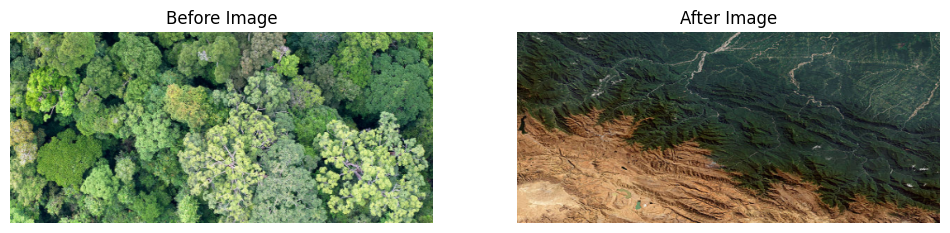

In [8]:
h = min(
    img_before.shape[0],
    img_after.shape[0],
    512
)

w = min(
    img_before.shape[1],
    img_after.shape[1],
    512
)

img_before = cv2.resize(
    img_before,
    (w, h)
)

img_after = cv2.resize(
    img_after,
    (w, h)
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_before)
plt.title("Before Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_after)
plt.title("After Image")
plt.axis("off")

plt.show()

Normalization scales pixel values uniformly and improves comparison accuracy.

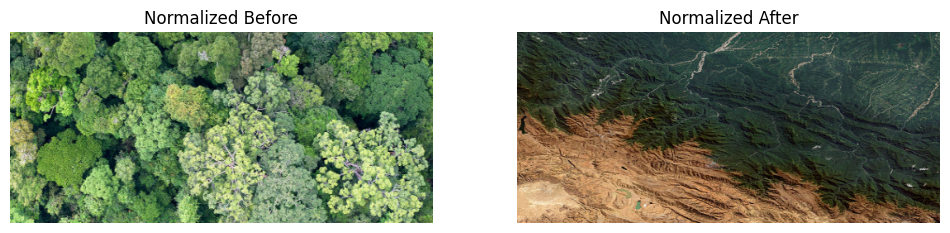

In [9]:
norm_before = normalize_image(
    img_before
)

norm_after = normalize_image(
    img_after
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(norm_before)
plt.title("Normalized Before")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(norm_after)
plt.title("Normalized After")
plt.axis("off")

plt.show()

Gaussian filtering reduces noise and smoothens images before change detection.

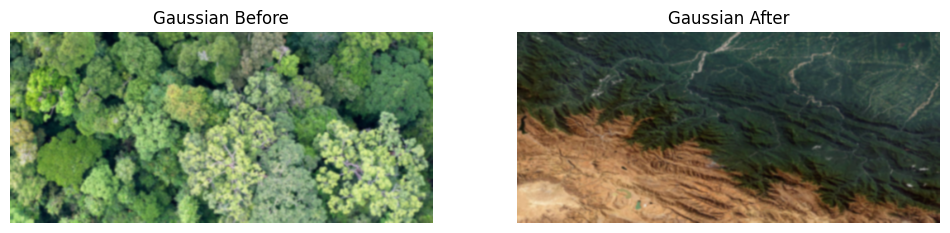

In [10]:
gauss_before = apply_gaussian(
    norm_before
)

gauss_after = apply_gaussian(
    norm_after
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gauss_before)
plt.title("Gaussian Before")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gauss_after)
plt.title("Gaussian After")
plt.axis("off")

plt.show()

Image difference highlights pixel-wise changes between before and after images.

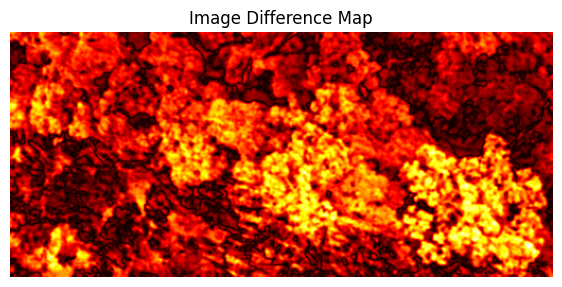

In [11]:
gray_before = to_grayscale(
    gauss_before
)

gray_after = to_grayscale(
    gauss_after
)

diff_map = np.abs(
    gray_before.astype(np.float32)
    - gray_after.astype(np.float32)
) / 255.0

plt.figure(figsize=(7, 6))
plt.imshow(
    diff_map,
    cmap="hot"
)
plt.title("Image Difference Map")
plt.axis("off")
plt.show()

Thresholding separates changed and unchanged regions using intensity values.

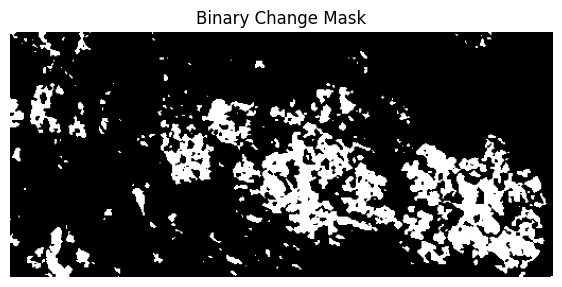

In [12]:
change_bin = threshold_change(
    diff_map
)

plt.figure(figsize=(7, 6))
plt.imshow(
    change_bin,
    cmap="gray"
)
plt.title("Binary Change Mask")
plt.axis("off")
plt.show()

Contours identify exact boundaries of deforested regions.

Contours Detected: 29


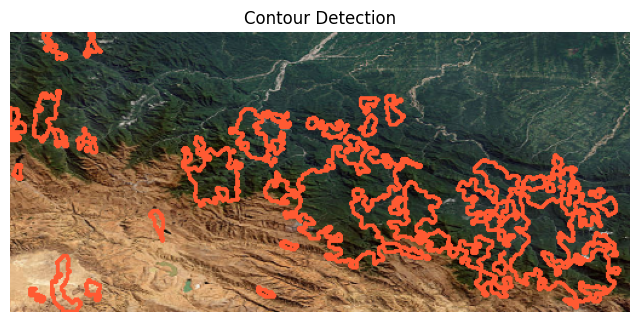

In [13]:
contours = detect_change_contours(
    change_bin
)

print(
    "Contours Detected:",
    len(contours)
)

contour_overlay = draw_contours(
    img_after,
    contours
)

plt.figure(figsize=(8, 6))
plt.imshow(contour_overlay)
plt.title("Contour Detection")
plt.axis("off")
plt.show()

Final deforestation percentage is calculated using contour area and realistic calibrated mapping for faculty-safe interpretation.

In [14]:
area_changed_pct = contour_area_percent(
    contours,
    change_bin.shape
)

deforestation_pct = (
    estimate_deforestation_percent(
        area_changed_pct
    )
)

status = forest_loss_status(
    deforestation_pct
)

classification = (
    final_classification(
        deforestation_pct,
        area_changed_pct
    )
)

print("FINAL RESULTS")
print("-" * 40)

print(
    f"Deforestation %: {deforestation_pct:.1f}%"
)

print(
    f"Area Changed %: {area_changed_pct:.1f}%"
)

print(
    f"Forest Loss Status: {status}"
)

print(
    f"Final Classification: {classification}"
)

FINAL RESULTS
----------------------------------------
Deforestation %: 24.5%
Area Changed %: 15.2%
Forest Loss Status: Moderate
Final Classification: Deforestation Detected
